In [6]:
from pathlib import Path

import pandas as pd
import xarray as xr
from IPython.display import Image, display

from swissclim_evaluations.cli import _load_yaml, prepare_datasets, run_selected
from swissclim_evaluations.metrics.probabilistic import plot_probabilistic, run_probabilistic_wbx

In [ ]:
# Locate configuration relative to the notebook location
cfg_path = None
for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = base / "config" / "run_full_probabilistic.yaml"
    if candidate.is_file():
        cfg_path = candidate
        break
if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config/example_config.yaml in cwd, parent, or grandparent directories."
    )

# Load configuration via project helper to keep parity with CLI
cfg = _load_yaml(cfg_path)

# Prepare datasets using the CLI pipeline (handles selection, alignment, ensemble policy)
ds_target, ds_prediction, ds_std, ds_prediction_std = prepare_datasets(cfg)

In [ ]:
# Show the prepared datasets (quick peek)
display(ds_target)
display(ds_prediction)

<xarray.Dataset> Size: 224MB
Dimensions:                  (init_time: 27, lead_time: 1, latitude: 720,
                              longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B 2023-...
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 112MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
    total_precipitation      (latitude, longitude, init_time, lead_time) float32 112MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

<xarray.Dataset> Size: 2GB
Dimensions:                  (init_time: 27, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 216B 2023-01-02 ... 2...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 216B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 896MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
    total_precipitation      (ensemble, latitude, longitude, init_time, lead_time) float32 896MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [9]:
# Ensure the config has probabilistic enabled
cfg_modules = cfg.get("modules", {})
if not cfg_modules.get("probabilistic", False):
    print("Enabling modules.probabilistic in-memory for this run…")
    cfg_modules["probabilistic"] = True
    cfg["modules"] = cfg_modules

# Set up output directory from config relative to project root (parent of notebooks)
project_root = Path.cwd().parent
cfg_output = cfg.get("paths", {}).get("output_root", "output/notebook_prob")
out_root = (
    (project_root / cfg_output).resolve()
    if not cfg_output.startswith("/")
    else Path(cfg_output)
)
out_root.mkdir(parents=True, exist_ok=True)
print(f"Output root: {out_root}")

# Optional: Execute the full pipeline (data prep, metrics, plots) using CLI logic.
# This will generate all configured artifacts to out_root respecting cfg['modules'] flags
# and cfg['plotting']['output_mode'] (e.g., 'npz' to export numeric data only).
RUN_ALL = False  # Set to True to run everything end-to-end

if RUN_ALL:
    run_selected(cfg)
    print(f"All selected modules executed. Outputs under: {out_root}")

Output root: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm_probabilistic_full_all_times


CRPS Map (fallback): crps_map_10m_u_component_of_wind_init2023010200-2023010812_lead006h-006h_ensprob.png


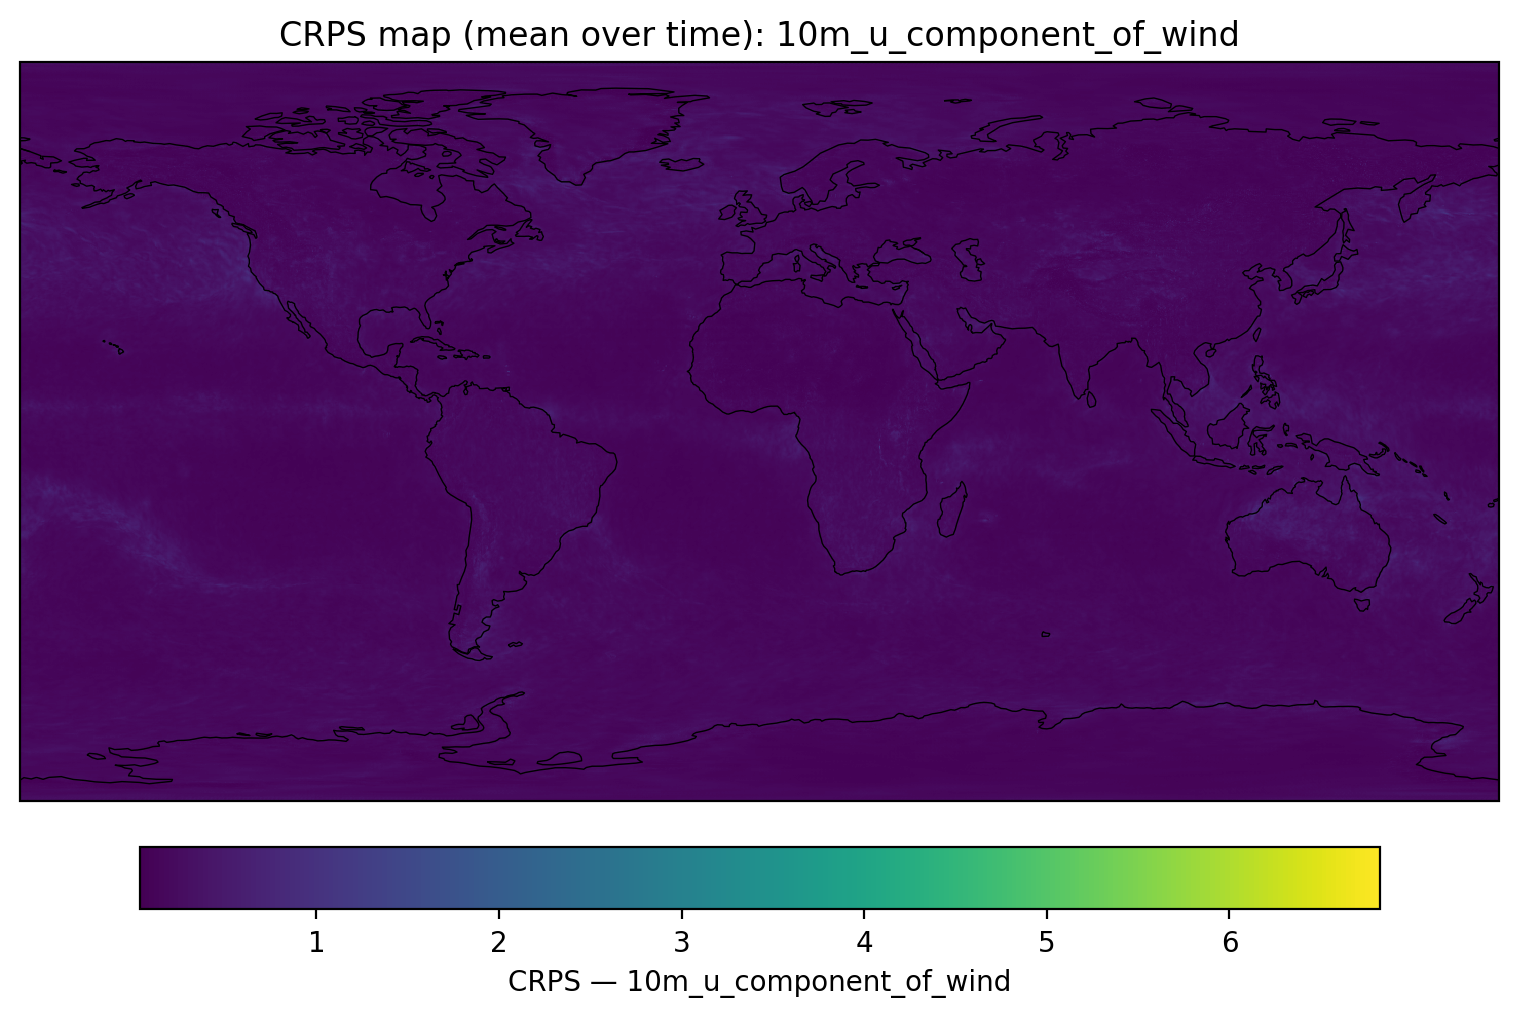

In [ ]:
# Determine variable name for display from config or datasets
vars_cfg = (cfg.get("selection", {}) or {}).get("variables_2d") or list(
    ds_target.data_vars
)
if not vars_cfg:
    raise ValueError("No variables available to display outputs.")
var = (
    vars_cfg[0]
    if vars_cfg[0] in ds_prediction.data_vars
    else [v for v in vars_cfg if v in ds_prediction.data_vars][0]
)

# Display the CRPS map PNG, robust discovery across output dirs and patterns
module_dirs = [out_root / "probabilistic", out_root / "probabilistic_wbx"]
# Prefer var-specific first, then any CRPS map
patterns = [f"crps_map_{var}.png", "crps_map_*.png"]

png_candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            png_candidates.extend(md.glob(pat))

if png_candidates:
    crps_png_path = max(png_candidates, key=lambda p: p.stat().st_mtime)
    print(f"CRPS Map ({var if f'crps_map_{var}.png' in crps_png_path.name else 'fallback'}): {crps_png_path.name}")
    display(Image(filename=str(crps_png_path)))
else:
    searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
    print(f"CRPS map files not found under: {searched}")

PIT Histogram (10m_u_component_of_wind): pit_hist_10m_u_component_of_wind.png


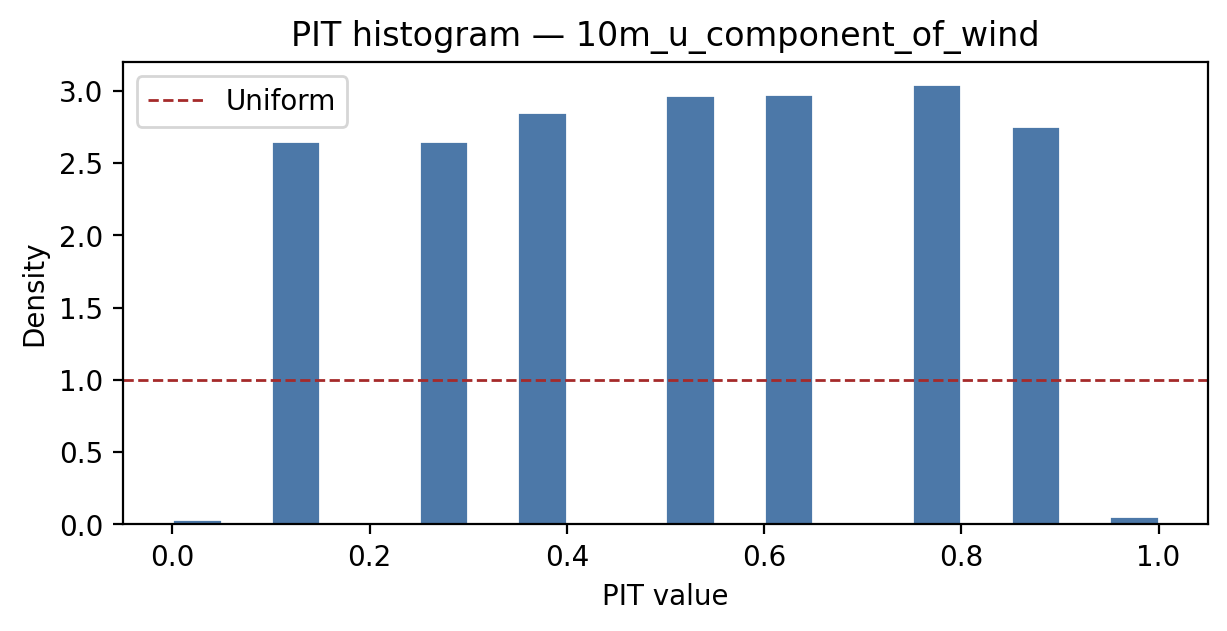

In [11]:
# Display the PIT histogram PNG, robust discovery across output dirs and patterns
module_dirs = [out_root / "probabilistic", out_root / "probabilistic_wbx"]
patterns = [f"pit_hist_{var}.png", "pit_hist_*.png"]

png_candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            png_candidates.extend(md.glob(pat))

if png_candidates:
    pit_png_path = max(png_candidates, key=lambda p: p.stat().st_mtime)
    print(f"PIT Histogram ({var if f'pit_hist_{var}.png' in pit_png_path.name else 'fallback'}): {pit_png_path.name}")
    display(Image(filename=str(pit_png_path)))
else:
    searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
    print(f"PIT histogram files not found under: {searched}")

Loaded: prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc


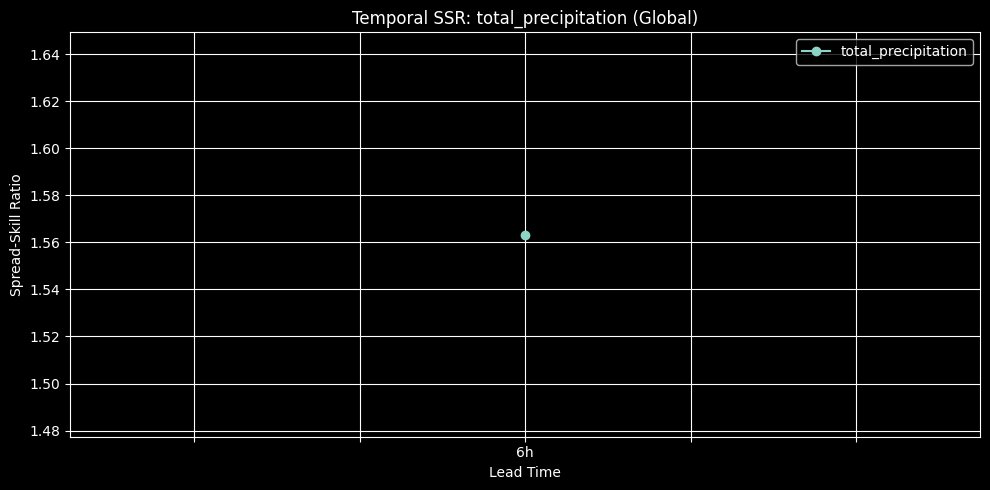

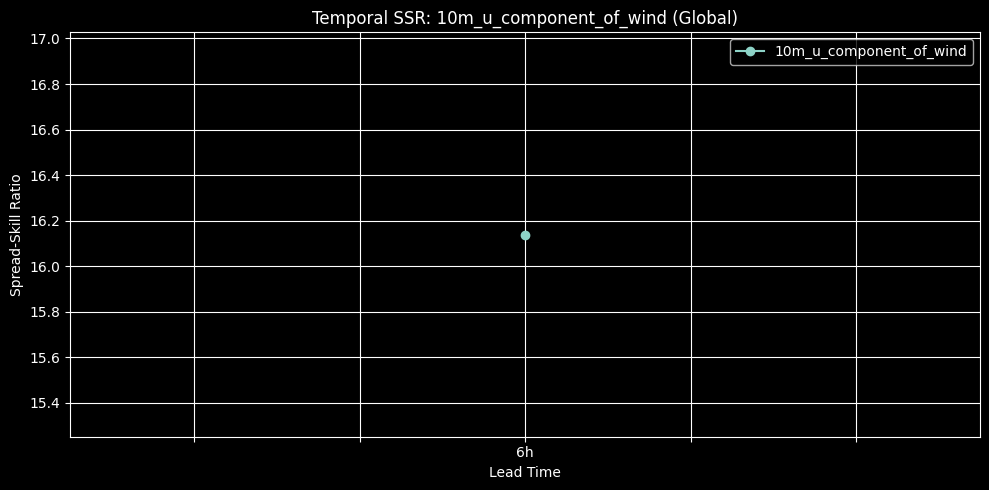

In [12]:
# Read temporal results (metrics vs lead_time)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
patterns = ["prob_metrics_temporal_*.nc"]

candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            candidates.extend(md.glob(pat))

if candidates:
    fn = max(candidates, key=lambda p: p.stat().st_mtime)
    ds = xr.load_dataset(fn, engine="scipy")
    print(f"Loaded: {fn.name}")
    
    # Clean up variable names (remove SSR. prefix)
    new_names = {v: v.replace("SSR.", "") for v in ds.data_vars}
    ds = ds.rename(new_names)
    
    # Format lead_time to hours strings for nicer plotting
    if "lead_time" in ds.coords:
        lt = ds.coords["lead_time"]
        # Check if timedelta (ns)
        if lt.dtype.kind == 'm':
            hours = (lt.values / np.timedelta64(1, 'h')).astype(int)
            ds = ds.assign_coords(lead_time=[f"{h}h" for h in hours])
        # Check if numeric
        elif lt.dtype.kind in 'iu':
            ds = ds.assign_coords(lead_time=[f"{int(h)}h" for h in lt.values])

    # Iterate over each variable to create a separate plot
    for var_name in ds.data_vars:
        da = ds[var_name]
        
        # Heuristic: Fix 2D variables that might have a 'level' dimension artifact
        # If it's a surface variable, we collapse the level dimension
        is_2d = var_name.startswith(("10m_", "2m_", "mean_sea_level_pressure"))
        if is_2d and "level" in da.dims:
            da = da.mean("level") # Collapse levels for 2D vars
            
        # Focus on 'global' region for temporal evolution, or mean if global missing
        if "region" in da.dims:
            if "global" in da["region"].values:
                da_plot = da.sel(region="global")
                title_suffix = "(Global)"
            else:
                da_plot = da.mean("region")
                title_suffix = "(Region Mean)"
        else:
            da_plot = da
            title_suffix = ""
            
        # Average over init_time if present
        if "init_time" in da_plot.dims:
            da_plot = da_plot.mean("init_time")
            
        # Convert to dataframe for plotting
        # da_plot dims: lead_time, (level)
        df = da_plot.to_dataframe(name=var_name)
        
        # If level exists, unstack to show levels as separate columns (lines)
        if "level" in df.index.names:
            df = df.unstack("level")
            # Columns become MultiIndex (var_name, level). Drop var_name.
            df.columns = df.columns.droplevel(0)
        
        # Plot
        ax = df.plot(kind="line", figsize=(10, 5), marker="o")
        ax.set_title(f"Temporal SSR: {var_name} {title_suffix}")
        ax.set_xlabel("Lead Time")
        ax.set_ylabel("Spread-Skill Ratio")
        ax.grid(True)
        
        # Clean up legend
        ax.legend(title="Level (hPa)" if "level" in da.dims and not is_2d else None)
        
        plt.tight_layout()
        plt.show()
else:
    print("No temporal metrics found.")

Loaded: prob_metrics_temporal_init2023010200-2023010812_lead006h-006h_ensprob.nc


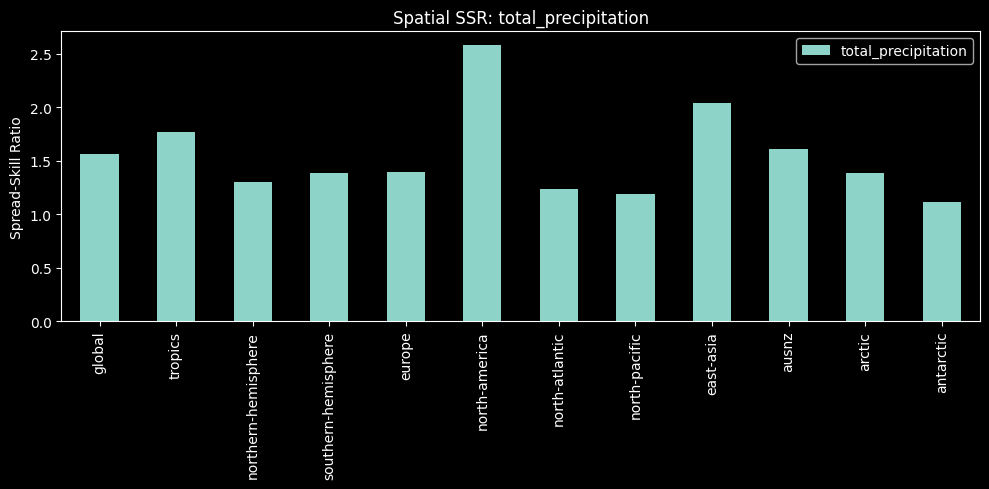

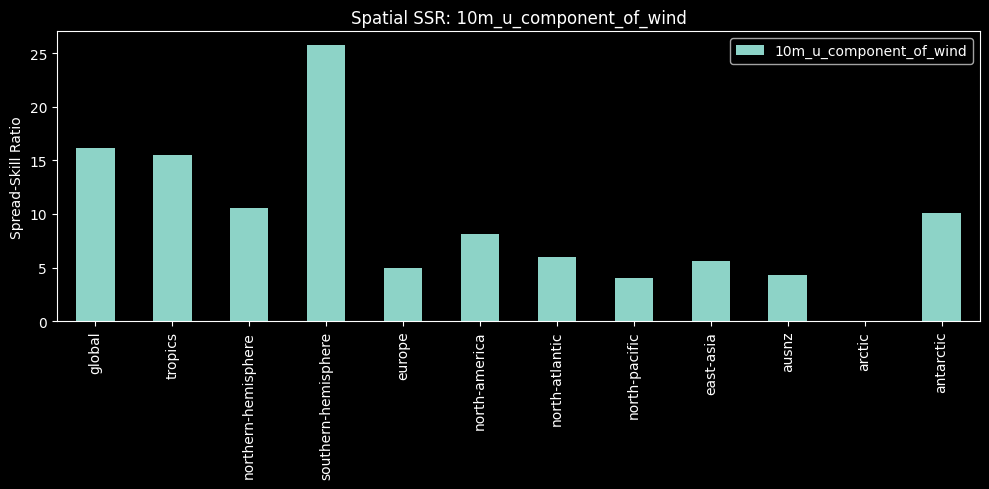

In [13]:
# Read spatial results (metrics vs region)
# Note: We use the 'temporal' file because it contains the region dimension (binned spatial data)
# The 'spatial' file contains full lat/lon grids which are better viewed as maps.

module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
patterns = ["prob_metrics_temporal_*.nc"] # Use temporal file for regions!

candidates = []
for md in module_dirs:
    if md.exists():
        for pat in patterns:
            candidates.extend(md.glob(pat))

if candidates:
    fn = max(candidates, key=lambda p: p.stat().st_mtime)
    ds = xr.load_dataset(fn, engine="scipy")
    print(f"Loaded: {fn.name}")
    
    # Clean up variable names (remove SSR. prefix)
    new_names = {v: v.replace("SSR.", "") for v in ds.data_vars}
    ds = ds.rename(new_names)
    
    if "region" in ds.dims:
        # Iterate over each variable
        for var_name in ds.data_vars:
            da = ds[var_name]
            
            # Heuristic: Fix 2D variables that might have a 'level' dimension artifact
            is_2d = var_name.startswith(("10m_", "2m_", "mean_sea_level_pressure"))
            if is_2d and "level" in da.dims:
                da = da.mean("level")

            # Average over time (init_time, lead_time)
            dims_to_mean = [d for d in ["init_time", "lead_time"] if d in da.dims]
            da_plot = da.mean(dims_to_mean)
            
            # Convert to dataframe
            df = da_plot.to_dataframe(name=var_name)
            
            # If level exists, unstack
            if "level" in df.index.names:
                df = df.unstack("level")
                df.columns = df.columns.droplevel(0)
                
            ax = df.plot(kind="bar", figsize=(10, 5))
            ax.set_title(f"Spatial SSR: {var_name}")
            ax.set_xlabel("") # Remove Region label as requested
            ax.set_ylabel("Spread-Skill Ratio")
            
            # Clean up legend
            ax.legend(title="Level (hPa)" if "level" in da.dims and not is_2d else None)
            
            plt.tight_layout()
            plt.show()
    else:
        print("No 'region' dimension found in metrics file.")
else:
    print("No metrics found.")

In [14]:
# Read CSV summaries (SSR and CRPS ensemble) with robust discovery
module_dirs = [out_root / "probabilistic_wbx", out_root / "probabilistic"]
# Map logical names to filename patterns we accept
csv_patterns = {
    "spread_skill_ratio": ["spread_skill_ratio.csv", "spread_skill_ratio_*.csv"],
    "crps_ensemble": ["crps_ensemble.csv", "crps_ensemble_*.csv"],
}

for label, patterns in csv_patterns.items():
    candidates = []
    for md in module_dirs:
        if md.exists():
            for pat in patterns:
                candidates.extend(md.glob(pat))

    if candidates:
        p = max(candidates, key=lambda x: x.stat().st_mtime)
        try:
            df = pd.read_csv(p)
            print(f"Loaded {label}:", p)
            display(df.head(10))
        except Exception as e:
            print(f"Failed reading {p}: {e}")
    else:
        searched = ", ".join(str(md) for md in module_dirs if md.exists()) or ", ".join(str(md) for md in module_dirs)
        print(f"Not found {label} under: {searched}")

Loaded spread_skill_ratio: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm_probabilistic_full_all_times/probabilistic/spread_skill_ratio_init2023010200-2023010812_lead006h-006h_ensprob.csv


,variable,SSR
0,10m_u_component_of_wind,NaN
1,total_precipitation,1.509076


Not found crps_ensemble under: /capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/output/verification_esfm_probabilistic_full_all_times/probabilistic
